In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler,OneHotEncoder
from sklearn.metrics import classification_report

# from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier


In [ ]:
df = pd.read_csv('C:\\Users\\Admin\\OneDrive\\Desktop\\data science\\ML\\SUPERVISED LEARNING\\Dataset\\vehicle_insurance.csv')

In [3]:
df

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...
381104,381105,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0
381105,381106,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0
381106,381107,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0
381107,381108,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0


In [4]:
df.duplicated().any()

np.False_

In [5]:
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [6]:
df.corr(numeric_only=True).Response

id                     -0.001368
Age                     0.111147
Driving_License         0.010155
Region_Code             0.010570
Previously_Insured     -0.341170
Annual_Premium          0.022575
Policy_Sales_Channel   -0.139042
Vintage                -0.001050
Response                1.000000
Name: Response, dtype: float64

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'id'),
  Text(1, 0, 'Age'),
  Text(2, 0, 'Driving_License'),
  Text(3, 0, 'Region_Code'),
  Text(4, 0, 'Previously_Insured'),
  Text(5, 0, 'Annual_Premium'),
  Text(6, 0, 'Policy_Sales_Channel'),
  Text(7, 0, 'Vintage'),
  Text(8, 0, 'Response')])

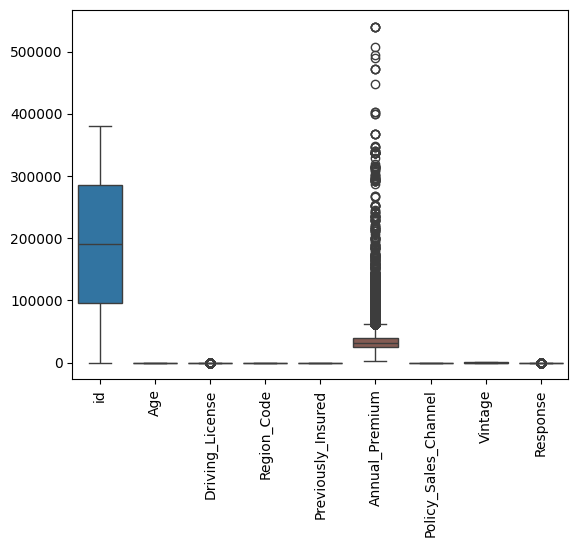

In [7]:
sns.boxplot(df)
plt.xticks(rotation=90)

In [8]:
X = df.drop(columns='Response')
y = df.Response

In [9]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns
# cat_cols.nunique()
# num_cols

In [10]:
xtrain, xtest, ytrain,ytest = train_test_split(X,y,train_size=0.8,random_state=42)

In [11]:
ytrain.value_counts()

Response
0    267700
1     37187
Name: count, dtype: int64

In [22]:
preprocessing = ColumnTransformer(
    transformers=[
        ('scaling',RobustScaler(),num_cols),
        ('encoder',OneHotEncoder(),cat_cols)
    ]
)
main_pipe = Pipeline(
    steps=[
        ('pre',preprocessing),
        ('model',DecisionTreeClassifier(class_weight='balanced'))
    ]
)

# main_pipe.fit(xtrain,ytrain)

In [24]:
grid_cv = GridSearchCV(
    estimator=main_pipe,
    param_grid={'model__criterion':['gini', 'entropy'],
                'model__splitter':['best', 'random'],
                'model__max_depth':[None,5,10,25,50],
                'model__max_features':['sqrt',1],
                'model__min_samples_split':[2,3,7,10],
                'model__min_samples_leaf':[1,3,5,7]
                },
    cv = 5,
    n_jobs=-1,
    verbose=2
)

In [25]:
grid_cv.fit(xtrain,ytrain)

Fitting 5 folds for each of 640 candidates, totalling 3200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 1], 'model__min_samples_leaf': [1, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

In [26]:
ytrain_pred = grid_cv.predict(xtrain)
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    267700
           1       1.00      1.00      1.00     37187

    accuracy                           1.00    304887
   macro avg       1.00      1.00      1.00    304887
weighted avg       1.00      1.00      1.00    304887



In [28]:
ytest_pred = grid_cv.predict(xtest)
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90     66699
           1       0.30      0.29      0.29      9523

    accuracy                           0.83     76222
   macro avg       0.60      0.60      0.60     76222
weighted avg       0.82      0.83      0.83     76222



**Conclusion**

The model performance is 100% well predict in training,test data also give 83% 

In [15]:
# preprocessing = ColumnTransformer(
#     transformers=[
#         ('scaling',RobustScaler(),num_cols),
#         ('encoder',OneHotEncoder(),cat_cols)
#     ]
# )
# main_pipe = Pipeline(
#     steps=[
#         ('pre',preprocessing),
#         ('model',RandomForestClassifier(class_weight='balanced',n_estimators=300))
#     ]
# )

# main_pipe.fit(xtrain,ytrain)

In [16]:
# ytrain_pred = main_pipe.predict(xtrain)
# print(classification_report(ytrain,ytrain_pred))

In [17]:
# ytest_pred = main_pipe.predict(xtest)
# print(classification_report(ytest,ytest_pred))

**conclusion**

in random forest also it is train data gives 100% accuracy test data gives 87%

In [18]:
# xtrain[cat_cols] = xtrain[cat_cols].astype('category')
# xtest[cat_cols] = xtest[cat_cols].astype('category')
# xtrain.info()

In [19]:
# main_pipe = XGBClassifier(enable_categorical = True, n_estimators=500)
# main_pipe.fit(xtrain,ytrain)

In [20]:
# ytrain_pred = main_pipe.predict(xtrain)
# print(classification_report(ytrain,ytrain_pred))

In [21]:
# ytest_pred = main_pipe.predict(xtest)
# print(classification_report(ytest,ytest_pred))